In [1]:
##Data editing

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
df_stocks = pd.read_csv("Stocks.csv")
df_spx = pd.read_csv("SPX.csv")
df_naics = pd.read_csv("naics.csv")

#Zuordnung Sektor-Code zu Sektor-Name einlesen (doppelt gequotete CSV)
import csv, io

sektor_namen = {}
with open("names.csv", encoding="utf-8-sig") as f:
    reader = csv.reader(f)  # erste Ebene: jede Zeile -> ein einzelnes, verschachteltes Feld
    zeilen = list(reader)

for zeile in zeilen[1:]:  # Kopfzeile überspringen
    code, titel = next(csv.reader(io.StringIO(zeile[0])))  # zweite Ebene: das eigentliche Feld parsen
    if "-" in code:
        start, ende = code.split("-")
        for c in range(int(start), int(ende) + 1):
            sektor_namen[str(c)] = titel
    else:
        sektor_namen[code] = titel

# --- Manuelle Überschreibung für Manufacturing-Sektoren ---
sektor_namen["31"] = "Convenience and Soft Goods"
sektor_namen["32"] = "Process and Material Processing"
sektor_namen["33"] = "Metal, Machinery and High-Tech"
sektor_namen["44"] = "Essential Retail"
sektor_namen["45"] = "Consumer Goods"



# Hilfsfunktion: ersetzt eine Sektor-Nummer in einem Spalten-/Zeilennamen durch den Klartext-Namen
import re

## sektor_name() anpassen: Name inkl. Sektor-Nummer in Klammern

def sektor_name(text):
    match = re.search(r'(\d+)$', str(text))
    if match and match.group(1) in sektor_namen:
        code = match.group(1)
        return f"{sektor_namen[code]} ({code})"
    return text


#calculate market capitalisation
df_stocks['mcap'] = abs(df_stocks['shrout'] * df_stocks['prc'])
df_stocks = df_stocks.dropna(subset=['mcap'])
#print (df_stocks)

#filter for market capitalisations excluding NaN
df_stocks_filtered = df_stocks[(df_stocks['mcap'].notna())]

#merge stocks with naics
df_stocks_merged = df_stocks_filtered.merge(df_naics, on='permno', how='left')

#csv file with only permnos and naics
df_sectors = df_stocks_merged[['permno', 'naics']]

#df_sectors with naics only once
df_sectors = df_sectors[df_sectors['naics'] != df_sectors['naics'].shift()]

#without NaN, duplicates, with integer naics and permnos and shortened to 2 digits
df_sectors = df_sectors.dropna(subset=['naics'])
df_sectors['naics'] = df_sectors['naics'].round(0).astype(int)
df_sectors['permno'] = df_sectors['permno'].round(0).astype(int)
df_sectors['naics'] = df_sectors['naics'].astype(str).str[:2]
df_sectors = df_sectors.drop_duplicates()

#find out which sectors are relevant (>10 permnos) and filter
counts = df_sectors.groupby('naics')['permno'].nunique().sort_values()
#print(counts)

#filter for naics with <10 permnos
naics_behalten = counts[counts >= 10].index
df_sectors = df_sectors[df_sectors['naics'].isin(naics_behalten)]

#sorted alphabetically by permno 
df_sectors = df_sectors.sort_values(by='permno', ascending=True)

df_sectors.to_csv('sectors.csv', index=False)




In [2]:
##monthly index and sector composition incl. weights & weighted returns

#SPX wide (permno, viele Datums-Spalten) to long (permno, date, wert) transformation
df_spx_long = df_spx.melt(id_vars='permno', var_name='date', value_name='in_index')
df_spx_long['date'] = pd.to_datetime(df_spx_long['date'])

#only keep stocks when in index
df_spx_long = df_spx_long[df_spx_long['in_index'] == 1]

#date to first of the month for fitting to SPX
df_stocks['date'] = pd.to_datetime(df_stocks['date']).dt.to_period('M').dt.to_timestamp()

#group by date and permnos as list 
ausgabe = df_stocks.groupby('date')['permno'].apply(list)

#for datum, permno_liste in ausgabe.items():
    #print(datum.strftime('%Y-%m-%d'), '->', permno_liste)

#calculating mcap
df_stocks['mcap'] = abs(df_stocks['shrout'] * df_stocks['prc'])


#Datum in Stocks.csv normalisieren
df_stocks['date'] = pd.to_datetime(df_stocks['date']).dt.to_period('M').dt.to_timestamp()

#mcap dazu holen (permno ist bereits in df_spx_long vorhanden, daher kein extra merge nötig für die ID selbst)
df_merged = df_spx_long.merge(
    df_stocks[['permno', 'date', 'mcap']],
    on=['permno', 'date'],
    how='left'
)

#pro Datum gruppieren: Liste der permnos + Summe der Marktkapitalisierung
ausgabe = df_merged.groupby('date').agg(
    permno=('permno', list),
    gesamt_mcap=('mcap', 'sum')
)

#for datum, row in ausgabe.iterrows():
    #print(datum.strftime('%Y-%m-%d'), '->', row['permno'], '| Summe mcap:', row['gesamt_mcap'])

#market capitalisation per naics (2 digits)
df_sectors_merge = df_sectors[['permno', 'naics']].copy()
df_sectors_merge['permno'] = df_sectors_merge['permno'].astype(df_merged['permno'].dtype)

df_merged_sektor = df_merged.merge(df_sectors_merge, on='permno', how='left')

sektor_mcap = df_merged_sektor.groupby(['date', 'naics'])['mcap'].sum()

# Gewicht jeder Aktie innerhalb ihres Sektors berechnen (Anteil an der Sektor-mcap)
df_merged_sektor = df_merged_sektor.merge(
    df_stocks[['permno', 'date', 'ret']],
    on=['permno', 'date'],
    how='left'
)

df_merged_sektor['sektor_mcap_summe'] = df_merged_sektor.groupby(['date', 'naics'])['mcap'].transform('sum')
df_merged_sektor['gewicht'] = df_merged_sektor['mcap'] / df_merged_sektor['sektor_mcap_summe']

# Gewicht jeder Aktie innerhalb des gesamten Index berechnen (Anteil an der Index-mcap)
df_merged['index_mcap_summe'] = df_merged.groupby('date')['mcap'].transform('sum')
df_merged['gewicht_index'] = df_merged['mcap'] / df_merged['index_mcap_summe']

# gewichteter Return je Aktie und daraus der gewichtete Sektor-Return
df_merged_sektor['gewichteter_return'] = df_merged_sektor['gewicht'] * df_merged_sektor['ret']
sektor_return = df_merged_sektor.groupby(['date', 'naics'])['gewichteter_return'].sum()

# gewichteter Return je Aktie und daraus der gewichtete Index-Return
df_merged = df_merged.merge(
    df_stocks[['permno', 'date', 'ret']],
    on=['permno', 'date'],
    how='left'
)
df_merged['gewichteter_return_index'] = df_merged['gewicht_index'] * df_merged['ret']
index_return = df_merged.groupby('date')['gewichteter_return_index'].sum()

# nur Zeitraum Januar 1980 bis inklusive Dezember 2019 ausgeben, inkl. Summe mcap Sektoren und Stocks
sektor_mcap_zeitraum = sektor_mcap[
    (sektor_mcap.index.get_level_values('date') >= '1980-01-01') &
    (sektor_mcap.index.get_level_values('date') <= '2019-12-31')
]

#for datum in sektor_mcap_zeitraum.index.get_level_values('date').unique():
    #print(datum.strftime('%Y-%m-%d'), '->')
    #for naics, mcap in sektor_mcap_zeitraum.loc[datum].items():
        #print('   Sektor', naics, ':', mcap)
    #summe_sektoren = sektor_mcap_zeitraum.loc[datum].sum()
    #summe_einzelaktien = ausgabe.loc[datum, 'gesamt_mcap']
    #print('   Summe aller Sektoren:', summe_sektoren)
    #print('   Summe aller Einzelaktien:', summe_einzelaktien)
    #for naics, ret in sektor_return.loc[datum].items():
        #print('   Gewichteter Return Sektor', naics, ':', ret)
    #print('   Gewichteter Return Index:', index_return.loc[datum])

In [26]:
## calculation of average weighted returns, max. and min. returns, median, standard deviation and sharpe ratio

# Sektor-Returns von Series (MultiIndex: date, naics) in wide-Format bringen
sektor_return_wide = sektor_return.unstack('naics')
sektor_return_wide.columns = [f'ret_sektor_{c}' for c in sektor_return_wide.columns]

# Index-Return als eigene Spalte
index_return_df = index_return.rename('ret_index').to_frame()

# Zusammenführen
df_returns = sektor_return_wide.join(index_return_df, how='left')

# nur Zeitraum Januar 1980 bis Dezember 2019
df_returns = df_returns[
    (df_returns.index >= '1980-01-01') &
    (df_returns.index <= '2019-12-31')
]

df_returns = df_returns.sort_index()

# Durchschnitt, Max, Min, Median je Sektor und Index über die Zeit
df_stats = pd.DataFrame({
    'mittelwert': df_returns.mean(),
    'maximum':    df_returns.max(),
    'minimum':    df_returns.min(),
    'median':     df_returns.median()
})

# Standardabweichung der monatlichen Returns je Sektor und Index
df_stats['std_abweichung'] = df_returns.std()

## Einlesen der risikofreien Rendite (DTB3) und Berechnung der Sharpe Ratios

df_rf = pd.read_csv("DTB3.csv")
df_rf['observation_date'] = pd.to_datetime(df_rf['observation_date'])

# jeden Wert durch 12 teilen (von p.a. auf einen monatlichen Näherungswert)
df_rf['DTB3'] = df_rf['DTB3'] / 12

# fehlende Tage (Feiertage) mit dem letzten bekannten Wert auffüllen
df_rf['DTB3'] = df_rf['DTB3'].ffill()

# auf Monatsebene aggregieren (Mittelwert der Tageswerte je Monat), um zu df_returns zu passen
df_rf['date'] = df_rf['observation_date'].dt.to_period('M').dt.to_timestamp()
df_rf_monatlich = df_rf.groupby('date')['DTB3'].mean().to_frame()

# von Prozent in Dezimalzahl umrechnen (z.B. 1.014 -> 0.01014), damit die Skala zu den Returns passt
df_rf_monatlich['DTB3'] = df_rf_monatlich['DTB3'] / 100

# mit den Sektor-/Index-Returns zusammenführen
df_returns_rf = df_returns.join(df_rf_monatlich, how='left')

# Sharpe Ratio je Sektor und Index berechnen
sharpe_ratios = {}
for spalte in df_returns.columns:
    ueberschuss_return = df_returns_rf[spalte] - df_returns_rf['DTB3']
    sharpe_ratios[spalte] = ueberschuss_return.mean() / ueberschuss_return.std()

df_stats['sharpe_ratio'] = pd.Series(sharpe_ratios)
df_stats

# Beta und Alpha gemäß CAPM berechnen (mit Excess Returns)
from scipy.stats import t as t_verteilung

markt_excess = df_returns_rf['ret_index'] - df_returns_rf['DTB3']

betas = {}
alphas = {}
beta_p_werte = {}
alpha_p_werte = {}

for spalte in df_returns.columns:
    asset_excess = df_returns_rf[spalte] - df_returns_rf['DTB3']
    daten = pd.concat([asset_excess, markt_excess], axis=1).dropna()
    daten.columns = ['asset', 'markt']

    n = len(daten)
    cov_matrix = np.cov(daten['asset'], daten['markt'])
    beta = cov_matrix[0, 1] / cov_matrix[1, 1]
    alpha = daten['asset'].mean() - beta * daten['markt'].mean()

    # Standardfehler und p-Werte für Beta und Alpha berechnen
    residuen = daten['asset'] - (alpha + beta * daten['markt'])
    s_residuen = np.sqrt(np.sum(residuen**2) / (n - 2))
    x_mean = daten['markt'].mean()
    ss_x = np.sum((daten['markt'] - x_mean)**2)

    se_beta = s_residuen / np.sqrt(ss_x)
    se_alpha = s_residuen * np.sqrt(1/n + x_mean**2/ss_x)

    t_stat_beta = beta / se_beta
    t_stat_alpha = alpha / se_alpha

    p_wert_beta = 2 * (1 - t_verteilung.cdf(abs(t_stat_beta), df=n-2))
    p_wert_alpha = 2 * (1 - t_verteilung.cdf(abs(t_stat_alpha), df=n-2))

    betas[spalte] = beta
    alphas[spalte] = alpha
    beta_p_werte[spalte] = p_wert_beta
    alpha_p_werte[spalte] = p_wert_alpha

df_stats['beta'] = pd.Series(betas)
df_stats['alpha'] = pd.Series(alphas)
df_stats['beta_p_wert'] = pd.Series(beta_p_werte)
df_stats['alpha_p_wert'] = pd.Series(alpha_p_werte)

# df_stats: Sektor-Nummern durch Klartext-Namen ersetzen
df_stats.index = df_stats.index.map(sektor_name)
df_stats = df_stats.rename(index={'ret_index': 'S&P 500'})

df_stats.to_excel("sektor_statistiken.xlsx", sheet_name="Statistiken", index=True)

C:\Users\User\AppData\Local\Temp\ipykernel_9980\1056444734.py:91: RuntimeWarning: divide by zero encountered in scalar divide
  t_stat_beta = beta / se_beta
C:\Users\User\AppData\Local\Temp\ipykernel_9980\1056444734.py:92: RuntimeWarning: invalid value encountered in scalar divide
  t_stat_alpha = alpha / se_alpha


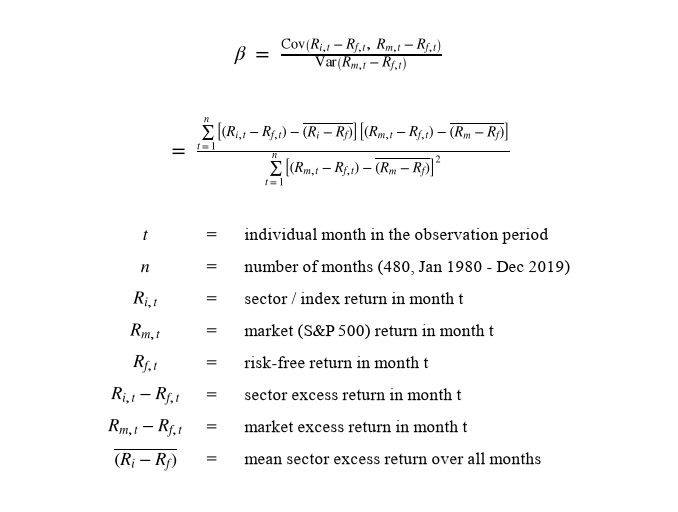

In [4]:
## calculation of beta (CAPM)

import matplotlib.pyplot as plt
import matplotlib as mpl
 
# Times New Roman verwenden (falls auf deinem Rechner installiert;
# in dieser Sandbox-Umgebung wird ersatzweise "Liberation Serif" genutzt,
# das metrisch mit Times New Roman identisch ist)
mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['mathtext.fontset'] = 'stix'   # Mathe-Schriftart im Times-Stil
 
legende = [
    (r'$t$', 'individual month in the observation period'),
    (r'$n$', 'number of months (480, Jan 1980 - Dec 2019)'),
    (r'$R_{i,t}$', 'sector / index return in month t'),
    (r'$R_{m,t}$', 'market (S&P 500) return in month t'),
    (r'$R_{f,t}$', 'risk-free return in month t'),
    (r'$R_{i,t} - R_{f,t}$', 'sector excess return in month t'),
    (r'$R_{m,t} - R_{f,t}$', 'market excess return in month t'),
    (r'$\overline{(R_i - R_f)}$', 'mean sector excess return over all months'),
]
 
fig, ax = plt.subplots(figsize=(8.5, 6.4))
ax.axis('off')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
 
# --- Doppelgleichung: Beta = Cov/Var = Summenformel ---
formel1 = r'$\beta \;=\; \frac{\mathrm{Cov}\left(R_{i,t}-R_{f,t},\; R_{m,t}-R_{f,t}\right)}{\mathrm{Var}\left(R_{m,t}-R_{f,t}\right)}$'
 
formel2 = (r'$=\; \frac{\sum_{t=1}^{n}\left[(R_{i,t}-R_{f,t})-\overline{(R_i-R_f)}\right]'
           r'\left[(R_{m,t}-R_{f,t})-\overline{(R_m-R_f)}\right]}'
           r'{\sum_{t=1}^{n}\left[(R_{m,t}-R_{f,t})-\overline{(R_m-R_f)}\right]^{2}}$')
 
ax.text(0.5, 0.94, formel1, ha='center', va='top', fontsize=15)
ax.text(0.5, 0.78, formel2, ha='center', va='top', fontsize=15)
 
# --- Legende: erst mit vorläufigen Positionen zeichnen, um Breiten zu messen ---
y_start = 0.54
zeilenabstand = 0.065
 
symbol_x = 0.35   # vorläufige Position, wird später verschoben
eq_x = 0.45
bed_x = 0.50
 
symbol_texte = []
eq_texte = []
bed_texte = []
 
for i, (symbol, bedeutung) in enumerate(legende):
    y = y_start - i * zeilenabstand
    t_sym = ax.text(symbol_x, y, symbol, ha='center', va='center', fontsize=13)
    t_eq  = ax.text(eq_x, y, '=', ha='center', va='center', fontsize=13)
    t_bed = ax.text(bed_x, y, bedeutung, ha='left', va='center', fontsize=12.5)
    symbol_texte.append(t_sym)
    eq_texte.append(t_eq)
    bed_texte.append(t_bed)
 
# Canvas einmal zeichnen, damit die tatsächlichen Text-Ausmaße bekannt sind
fig.canvas.draw()
inv = ax.transAxes.inverted()
 
# linkesten Rand der Symbol-Spalte und rechtesten Rand der Bedeutungs-Spalte ermitteln
min_x = min(inv.transform(t.get_window_extent(fig.canvas.get_renderer()))[0][0] for t in symbol_texte)
max_x = max(inv.transform(t.get_window_extent(fig.canvas.get_renderer()))[1][0] for t in bed_texte)
 
block_mitte = (min_x + max_x) / 2
verschiebung = 0.5 - block_mitte   # Distanz, um den Block auf x=0.5 zu zentrieren
 
# alle Texte um diese Distanz verschieben
for t in symbol_texte + eq_texte + bed_texte:
    x, y = t.get_position()
    t.set_position((x + verschiebung, y))
 
plt.savefig('beta_formel_mit_legende.png', dpi=600, bbox_inches='tight', facecolor='white')
plt.show()

Index(['mittelwert', 'maximum', 'minimum', 'median', 'std_abweichung',
       'sharpe_ratio', 'beta', 'alpha', 'beta_p_wert', 'alpha_p_wert'],
      dtype='str')


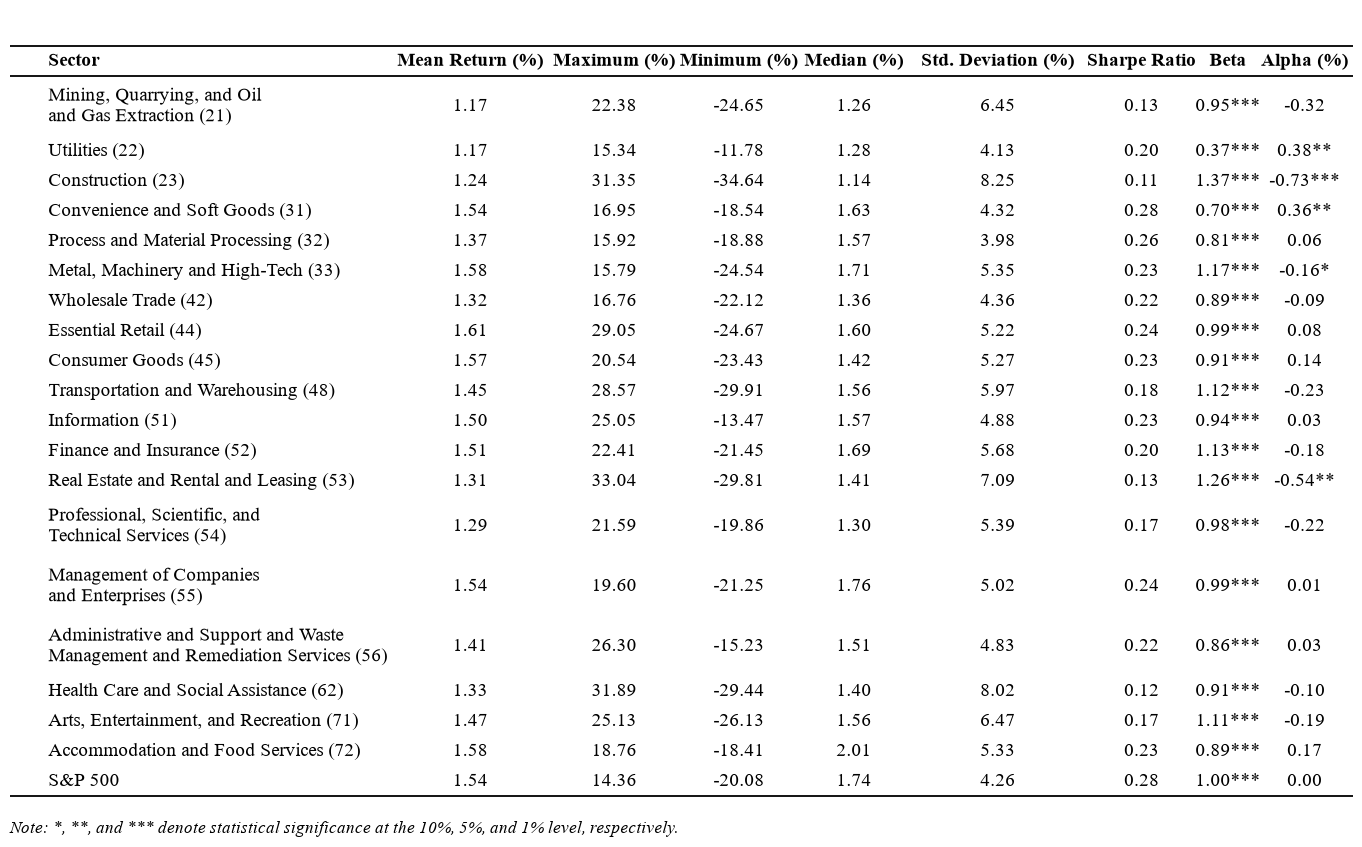

In [30]:
## df_stats als table plot
import re
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Times New Roman'

def signifikanz_sterne(p):
    if p < 0.01:
        return '***'
    elif p < 0.05:
        return '**'
    elif p < 0.10:
        return '*'
    else:
        return ''
    
print(df_stats.columns)

tabelle = df_stats.reset_index()
tabelle = tabelle.rename(columns={
    'index': 'Sector',
    'mittelwert': 'Mean Return',
    'maximum': 'Maximum',
    'minimum': 'Minimum',
    'median': 'Median',
    'std_abweichung': 'Std. Deviation',
    'sharpe_ratio': 'Sharpe Ratio',
    'beta': 'Beta' ,
    'alpha': 'Alpha'  
})

def sortier_schluessel(name):
    if name == 'S&P 500':
        return float('inf')
    match = re.search(r'\((\d+)\)$', name)
    return int(match.group(1)) if match else float('inf') - 1

tabelle['sortier_key'] = tabelle['Sector'].map(sortier_schluessel)
tabelle = tabelle.sort_values('sortier_key').drop(columns='sortier_key')

umbrueche = {
    'Mining, Quarrying, and Oil and Gas Extraction (21)':
        'Mining, Quarrying, and Oil\nand Gas Extraction (21)',
    'Professional, Scientific, and Technical Services (54)':
        'Professional, Scientific, and\nTechnical Services (54)',
    'Administrative and Support and Waste Management and Remediation Services (56)':
        'Administrative and Support and Waste\nManagement and Remediation Services (56)',
    'Management of Companies and Enterprises (55)':
        'Management of Companies\nand Enterprises (55)',
}
for alt, neu in umbrueche.items():
    tabelle['Sector'] = tabelle['Sector'].str.replace(alt, neu, regex=False)

prozent_spalten = ['Mean Return', 'Maximum', 'Minimum', 'Median', 'Std. Deviation']
for spalte in prozent_spalten:
    tabelle[spalte] = (tabelle[spalte] * 100).round(2).map(lambda x: f'{x:,.2f}')

tabelle['Sharpe Ratio'] = tabelle['Sharpe Ratio'].round(2).map(lambda x: f'{x:,.2f}')

# Sternchen berechnen und an Beta/Alpha anhängen
tabelle['beta_sterne'] = tabelle['beta_p_wert'].map(signifikanz_sterne)
tabelle['alpha_sterne'] = tabelle['alpha_p_wert'].map(signifikanz_sterne)

tabelle['Beta'] = tabelle['Beta'].round(2).map(lambda x: f'{x:,.2f}') + tabelle['beta_sterne']
tabelle['Alpha'] = (tabelle['Alpha'] * 100).round(2).map(lambda x: f'{x:,.2f}') + tabelle['alpha_sterne']

prozent_spalten.append('Alpha')

# Hilfsspalten wieder entfernen, bevor die Tabelle gerendert wird
tabelle = tabelle.drop(columns=['beta_p_wert', 'alpha_p_wert', 'beta_sterne', 'alpha_sterne'])

col_labels = list(tabelle.columns)
for spalte in prozent_spalten:
    col_labels[col_labels.index(spalte)] = f'{spalte} (%)'

n_rows = len(tabelle)
n_cols = len(col_labels)

fig, ax = plt.subplots(figsize=(1.3 * n_cols + 2, 0.38 * n_rows + 0.8))
ax.axis('off')

#äußere Ränder der Figure verkleinern, damit die Tabelle mehr Platz hat
fig.subplots_adjust(left=0.01, right=0.99, top=0.99, bottom=0.01)

# individuelle Spaltenbreiten festlegen
breiten_übersteuerung = {
    'Mean Return (%)': 0.08,
    'Sector': 0.07,
    'Sharpe Ratio': 0.06,
    'Beta': 0.03,
    'Alpha (%)': 0.05,
    'Median (%)': 0.06,
    'Minimum (%)': 0.06,
    'Maximum (%)': 0.07,
    'Std. Deviation (%)': 0.09,
}

standardbreite = 0.7 / (n_cols - 1)

spaltenbreiten = []
for label in col_labels:
    if label == 'Sector':
        spaltenbreiten.append(0.20)
    elif label in breiten_übersteuerung:
        spaltenbreiten.append(breiten_übersteuerung[label])
    else:
        spaltenbreiten.append(standardbreite)

summe = sum(spaltenbreiten)
spaltenbreiten = [b / summe for b in spaltenbreiten]

tab = ax.table(
    cellText=tabelle.values,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
    colWidths=spaltenbreiten          
)

tab.auto_set_font_size(False)
tab.set_fontsize(14)
tab.scale(1, 1.8)

umbruch_zeilen = [i + 1 for i, name in enumerate(tabelle['Sector']) if '\n' in name]

for (row, col), cell in tab.get_celld().items():
    cell.set_linewidth(0)
    cell.visible_edges = ''
    cell.set_text_props(fontfamily='Times New Roman')
    if col == 0:
        cell.set_text_props(ha='left', fontfamily='Times New Roman')
    if row == 0:
        cell.set_text_props(weight='bold', fontfamily='Times New Roman')
        cell.visible_edges = 'B'
        cell.set_linewidth(1.3)
    if row in umbruch_zeilen:
        cell.set_height(cell.get_height() * 2)

fig.canvas.draw()
bbox = tab.get_window_extent(fig.canvas.get_renderer()).transformed(ax.transAxes.inverted())

ax.hlines([bbox.y1, bbox.y0], xmin=bbox.x0, xmax=bbox.x1, transform=ax.transAxes,
          color='black', linewidth=1.3, clip_on=False)

# Fußnote zur Signifikanz-Notation
ax.text(
    bbox.x0, bbox.y0 - 0.03,
    'Note: *, **, and *** denote statistical significance at the 10%, 5%, and 1% level, respectively.',
    transform=ax.transAxes,
    ha='left', va='top',
    fontsize=12, fontstyle='italic',
    fontfamily='Times New Roman'
)

plt.savefig('stats_table.png', dpi=600, bbox_inches='tight', facecolor='white')
plt.show()

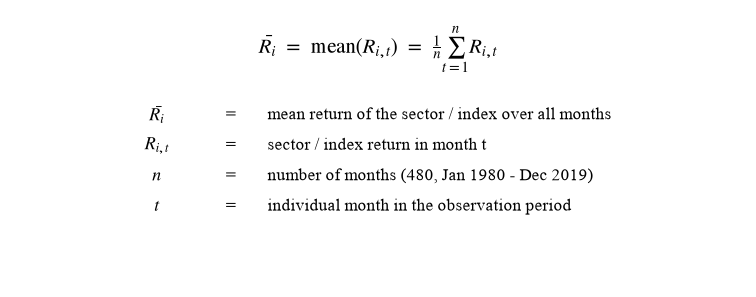

In [6]:
##Mean formula plot
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['mathtext.fontset'] = 'stix'

legende = [
    (r'$\bar{R_i}$', 'mean return of the sector / index over all months'),
    (r'$R_{i,t}$', 'sector / index return in month t'),
    (r'$n$', 'number of months (480, Jan 1980 - Dec 2019)'),
    (r'$t$', 'individual month in the observation period'),
    
   
    
]

fig, ax = plt.subplots(figsize=(9.5, 3.6))
ax.axis('off')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# --- Doppelgleichung in einer Zeile ---
formel = r'$\bar{R_i} \;=\; \mathrm{mean}(R_{i,t}) \;=\; \frac{1}{n}\sum_{t=1}^{n} R_{i,t}$'
ax.text(0.5, 0.94, formel, ha='center', va='top', fontsize=15)

# --- Legende darunter ---
y_start = 0.62
zeilenabstand = 0.11

symbol_x = 0.35
eq_x = 0.45
bed_x = 0.50

symbol_texte, eq_texte, bed_texte = [], [], []

for i, (symbol, bedeutung) in enumerate(legende):
    y = y_start - i * zeilenabstand
    t_sym = ax.text(symbol_x, y, symbol, ha='center', va='center', fontsize=13)
    t_eq  = ax.text(eq_x, y, '=', ha='center', va='center', fontsize=13)
    t_bed = ax.text(bed_x, y, bedeutung, ha='left', va='center', fontsize=12.5)
    symbol_texte.append(t_sym)
    eq_texte.append(t_eq)
    bed_texte.append(t_bed)

fig.canvas.draw()
inv = ax.transAxes.inverted()

min_x = min(inv.transform(t.get_window_extent(fig.canvas.get_renderer()))[0][0] for t in symbol_texte)
max_x = max(inv.transform(t.get_window_extent(fig.canvas.get_renderer()))[1][0] for t in bed_texte)

block_mitte = (min_x + max_x) / 2
verschiebung = 0.5 - block_mitte

for t in symbol_texte + eq_texte + bed_texte:
    x, y = t.get_position()
    t.set_position((x + verschiebung, y))

plt.savefig('mean_formel_mit_legende.png', dpi=600, bbox_inches='tight', facecolor='white')
plt.show()

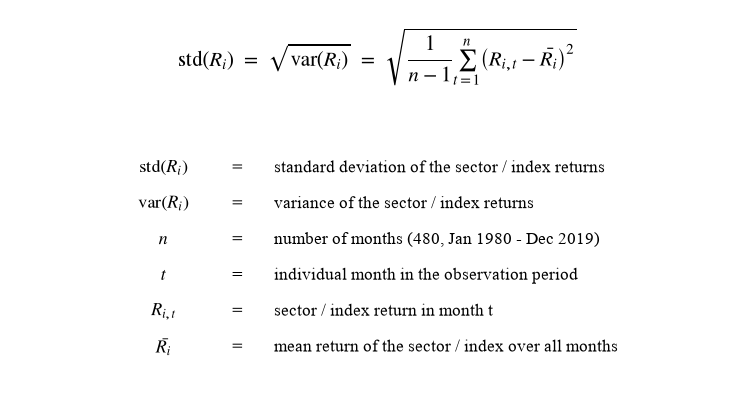

In [7]:
## plot sharpe ratio formula

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['mathtext.fontset'] = 'stix'

# Reihenfolge nach erstem Auftreten in der Formel:
# std(R_i) = sqrt(var(R_i)) = sqrt( 1/(n-1) * sum_{t=1}^{n} (R_{i,t} - R̄_i)^2 )
legende = [
    (r'$\mathrm{std}(R_i)$', 'standard deviation of the sector / index returns'),
    (r'$\mathrm{var}(R_i)$', 'variance of the sector / index returns'),
    (r'$n$', 'number of months (480, Jan 1980 - Dec 2019)'),
    (r'$t$', 'individual month in the observation period'),
    (r'$R_{i,t}$', 'sector / index return in month t'),
    (r'$\bar{R_i}$', 'mean return of the sector / index over all months'),
]

fig, ax = plt.subplots(figsize=(9.5, 4.9))
ax.axis('off')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# --- Doppelgleichung in einer Zeile ---
formel = (r'$\mathrm{std}(R_i) \;=\; \sqrt{\mathrm{var}(R_i)} \;=\; '
          r'\sqrt{\dfrac{1}{n-1}\sum_{t=1}^{n}\left(R_{i,t} - \bar{R_i}\right)^{2}}$')

ax.text(0.5, 0.95, formel, ha='center', va='top', fontsize=15)

# --- Legende darunter ---
y_start = 0.58
zeilenabstand = 0.095

symbol_x = 0.35
eq_x = 0.45
bed_x = 0.50

symbol_texte, eq_texte, bed_texte = [], [], []

for i, (symbol, bedeutung) in enumerate(legende):
    y = y_start - i * zeilenabstand
    t_sym = ax.text(symbol_x, y, symbol, ha='center', va='center', fontsize=13)
    t_eq  = ax.text(eq_x, y, '=', ha='center', va='center', fontsize=13)
    t_bed = ax.text(bed_x, y, bedeutung, ha='left', va='center', fontsize=12.5)
    symbol_texte.append(t_sym)
    eq_texte.append(t_eq)
    bed_texte.append(t_bed)

# Canvas einmal zeichnen, damit die tatsächlichen Text-Ausmaße bekannt sind
fig.canvas.draw()
inv = ax.transAxes.inverted()

# linkesten Rand der Symbol-Spalte und rechtesten Rand der Bedeutungs-Spalte ermitteln
min_x = min(inv.transform(t.get_window_extent(fig.canvas.get_renderer()))[0][0] for t in symbol_texte)
max_x = max(inv.transform(t.get_window_extent(fig.canvas.get_renderer()))[1][0] for t in bed_texte)

block_mitte = (min_x + max_x) / 2
verschiebung = 0.5 - block_mitte   # Distanz, um den Block auf x=0.5 zu zentrieren

# alle Texte um diese Distanz verschieben
for t in symbol_texte + eq_texte + bed_texte:
    x, y = t.get_position()
    t.set_position((x + verschiebung, y))

plt.savefig('std_formel_mit_legende.png', dpi=600, bbox_inches='tight', facecolor='white')
plt.show()

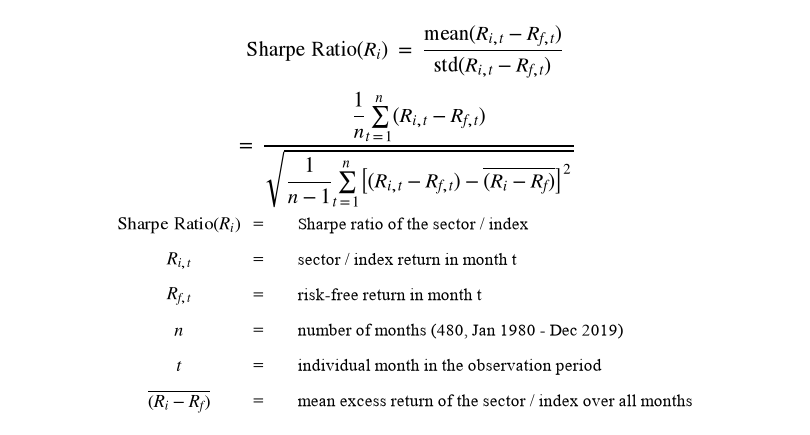

In [8]:
## sharpe ratio formula plot

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['mathtext.fontset'] = 'stix'

# Reihenfolge nach erstem Auftreten in der Formel:
# Sharpe Ratio(R_i) = mean(R_i,t - R_f,t) / std(R_i,t - R_f,t)
#                   = [ (1/n) sum_{t=1}^n (R_i,t - R_f,t) ] / [ sqrt( 1/(n-1) sum_{t=1}^n ((R_i,t-R_f,t) - mean(R_i-R_f))^2 ) ]
legende = [
    (r'$\mathrm{Sharpe\ Ratio}(R_i)$', 'Sharpe ratio of the sector / index'),
    (r'$R_{i,t}$', 'sector / index return in month t'),
    (r'$R_{f,t}$', 'risk-free return in month t'),
    (r'$n$', 'number of months (480, Jan 1980 - Dec 2019)'),
    (r'$t$', 'individual month in the observation period'),
    (r'$\overline{(R_i - R_f)}$', 'mean excess return of the sector / index over all months'),
]

fig, ax = plt.subplots(figsize=(10.2, 5.4))
ax.axis('off')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# --- Doppelgleichung, gestapelt (Code-Notation oben, Summenformel unten) ---
formel1 = r'$\mathrm{Sharpe\ Ratio}(R_i) \;=\; \dfrac{\mathrm{mean}(R_{i,t} - R_{f,t})}{\mathrm{std}(R_{i,t} - R_{f,t})}$'

formel2 = (r'$=\; \dfrac{\dfrac{1}{n}\sum_{t=1}^{n}(R_{i,t}-R_{f,t})}'
           r'{\sqrt{\dfrac{1}{n-1}\sum_{t=1}^{n}\left[(R_{i,t}-R_{f,t})-\overline{(R_i-R_f)}\right]^{2}}}$')

ax.text(0.5, 0.96, formel1, ha='center', va='top', fontsize=15)
ax.text(0.5, 0.80, formel2, ha='center', va='top', fontsize=15)

# --- Legende darunter ---
y_start = 0.48
zeilenabstand = 0.085

symbol_x = 0.35
eq_x = 0.45
bed_x = 0.50

symbol_texte, eq_texte, bed_texte = [], [], []

for i, (symbol, bedeutung) in enumerate(legende):
    y = y_start - i * zeilenabstand
    t_sym = ax.text(symbol_x, y, symbol, ha='center', va='center', fontsize=13)
    t_eq  = ax.text(eq_x, y, '=', ha='center', va='center', fontsize=13)
    t_bed = ax.text(bed_x, y, bedeutung, ha='left', va='center', fontsize=12.5)
    symbol_texte.append(t_sym)
    eq_texte.append(t_eq)
    bed_texte.append(t_bed)

# Canvas einmal zeichnen, damit die tatsächlichen Text-Ausmaße bekannt sind
fig.canvas.draw()
inv = ax.transAxes.inverted()

# linkesten Rand der Symbol-Spalte und rechtesten Rand der Bedeutungs-Spalte ermitteln
min_x = min(inv.transform(t.get_window_extent(fig.canvas.get_renderer()))[0][0] for t in symbol_texte)
max_x = max(inv.transform(t.get_window_extent(fig.canvas.get_renderer()))[1][0] for t in bed_texte)

block_mitte = (min_x + max_x) / 2
verschiebung = 0.5 - block_mitte   # Distanz, um den Block auf x=0.5 zu zentrieren

# alle Texte um diese Distanz verschieben
for t in symbol_texte + eq_texte + bed_texte:
    x, y = t.get_position()
    t.set_position((x + verschiebung, y))

plt.savefig('sharpe_formel_mit_legende.png', dpi=600, bbox_inches='tight', facecolor='white')
plt.show()

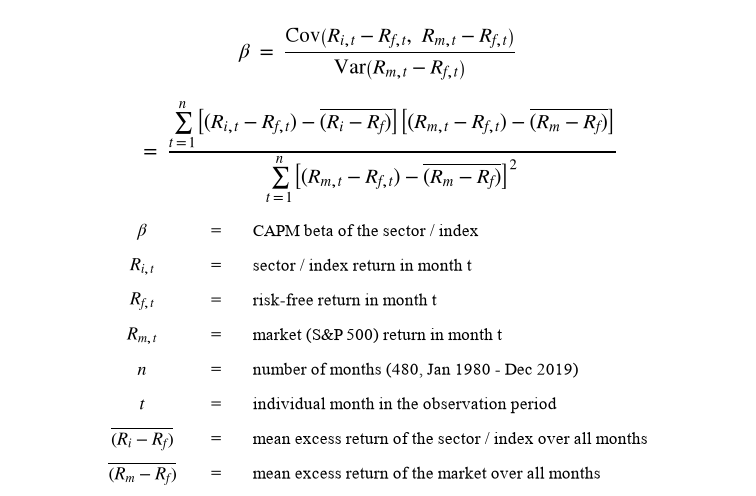

In [9]:
## beta formula plot

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['mathtext.fontset'] = 'stix'

# Reihenfolge nach erstem Auftreten in der Formel:
# beta = Cov(R_i,t-R_f,t, R_m,t-R_f,t) / Var(R_m,t-R_f,t)
#      = Sum_{t=1}^{n}[(R_i,t-R_f,t)-mean(R_i-R_f)][(R_m,t-R_f,t)-mean(R_m-R_f)] / Sum_{t=1}^{n}[(R_m,t-R_f,t)-mean(R_m-R_f)]^2
legende = [
    (r'$\beta$', 'CAPM beta of the sector / index'),
    (r'$R_{i,t}$', 'sector / index return in month t'),
    (r'$R_{f,t}$', 'risk-free return in month t'),
    (r'$R_{m,t}$', 'market (S&P 500) return in month t'),
    (r'$n$', 'number of months (480, Jan 1980 - Dec 2019)'),
    (r'$t$', 'individual month in the observation period'),
    (r'$\overline{(R_i - R_f)}$', 'mean excess return of the sector / index over all months'),
    (r'$\overline{(R_m - R_f)}$', 'mean excess return of the market over all months'),
]

fig, ax = plt.subplots(figsize=(9.5, 6.0))
ax.axis('off')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# --- Doppelgleichung, gestapelt (Code-Notation oben, Summenformel unten) ---
formel1 = r'$\beta \;=\; \dfrac{\mathrm{Cov}\left(R_{i,t}-R_{f,t},\; R_{m,t}-R_{f,t}\right)}{\mathrm{Var}\left(R_{m,t}-R_{f,t}\right)}$'

formel2 = (r'$=\; \dfrac{\sum_{t=1}^{n}\left[(R_{i,t}-R_{f,t})-\overline{(R_i-R_f)}\right]'
           r'\left[(R_{m,t}-R_{f,t})-\overline{(R_m-R_f)}\right]}'
           r'{\sum_{t=1}^{n}\left[(R_{m,t}-R_{f,t})-\overline{(R_m-R_f)}\right]^{2}}$')

ax.text(0.5, 0.96, formel1, ha='center', va='top', fontsize=15)
ax.text(0.5, 0.80, formel2, ha='center', va='top', fontsize=15)

# --- Legende darunter (Abstand halbiert: y_start 0.45 -> 0.518) ---
y_start = 0.518
zeilenabstand = 0.075

symbol_x = 0.35
eq_x = 0.45
bed_x = 0.50

symbol_texte, eq_texte, bed_texte = [], [], []

for i, (symbol, bedeutung) in enumerate(legende):
    y = y_start - i * zeilenabstand
    t_sym = ax.text(symbol_x, y, symbol, ha='center', va='center', fontsize=13)
    t_eq  = ax.text(eq_x, y, '=', ha='center', va='center', fontsize=13)
    t_bed = ax.text(bed_x, y, bedeutung, ha='left', va='center', fontsize=12.5)
    symbol_texte.append(t_sym)
    eq_texte.append(t_eq)
    bed_texte.append(t_bed)

fig.canvas.draw()
inv = ax.transAxes.inverted()

min_x = min(inv.transform(t.get_window_extent(fig.canvas.get_renderer()))[0][0] for t in symbol_texte)
max_x = max(inv.transform(t.get_window_extent(fig.canvas.get_renderer()))[1][0] for t in bed_texte)

block_mitte = (min_x + max_x) / 2
verschiebung = 0.5 - block_mitte

for t in symbol_texte + eq_texte + bed_texte:
    x, y = t.get_position()
    t.set_position((x + verschiebung, y))

plt.savefig('beta_formel_mit_legende_final.png', dpi=600, bbox_inches='tight', facecolor='white')
plt.show()

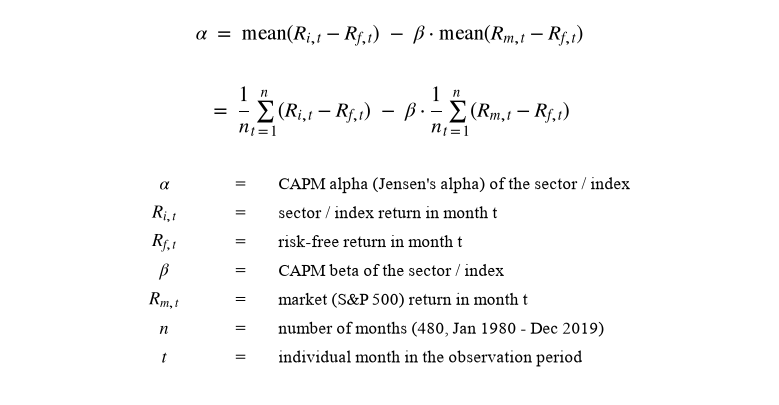

In [10]:
## Alpha formula plot

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['mathtext.fontset'] = 'stix'

# Reihenfolge nach erstem Auftreten in der Formel:
# alpha = mean(R_i,t - R_f,t) - beta * mean(R_m,t - R_f,t)
#       = (1/n) sum_{t=1}^n (R_i,t-R_f,t) - beta * (1/n) sum_{t=1}^n (R_m,t-R_f,t)
legende = [
    (r'$\alpha$', "CAPM alpha (Jensen's alpha) of the sector / index"),
    (r'$R_{i,t}$', 'sector / index return in month t'),
    (r'$R_{f,t}$', 'risk-free return in month t'),
    (r'$\beta$', 'CAPM beta of the sector / index'),
    (r'$R_{m,t}$', 'market (S&P 500) return in month t'),
    (r'$n$', 'number of months (480, Jan 1980 - Dec 2019)'),
    (r'$t$', 'individual month in the observation period'),
]

fig, ax = plt.subplots(figsize=(9.8, 5.0))
ax.axis('off')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# --- Doppelgleichung, gestapelt (Code-Notation oben, Summenformel unten) ---
formel1 = r'$\alpha \;=\; \mathrm{mean}(R_{i,t} - R_{f,t}) \;-\; \beta \cdot \mathrm{mean}(R_{m,t} - R_{f,t})$'

formel2 = (r'$=\; \dfrac{1}{n}\sum_{t=1}^{n}(R_{i,t}-R_{f,t}) '
           r'\;-\; \beta \cdot \dfrac{1}{n}\sum_{t=1}^{n}(R_{m,t}-R_{f,t})$')

ax.text(0.5, 0.96, formel1, ha='center', va='top', fontsize=15)
ax.text(0.5, 0.80, formel2, ha='center', va='top', fontsize=15)

# --- Legende darunter (Abstand leicht vergrößert: y_start 0.603 -> 0.545) ---
y_start = 0.545
zeilenabstand = 0.075

symbol_x = 0.35
eq_x = 0.45
bed_x = 0.50

symbol_texte, eq_texte, bed_texte = [], [], []

for i, (symbol, bedeutung) in enumerate(legende):
    y = y_start - i * zeilenabstand
    t_sym = ax.text(symbol_x, y, symbol, ha='center', va='center', fontsize=13)
    t_eq  = ax.text(eq_x, y, '=', ha='center', va='center', fontsize=13)
    t_bed = ax.text(bed_x, y, bedeutung, ha='left', va='center', fontsize=12.5)
    symbol_texte.append(t_sym)
    eq_texte.append(t_eq)
    bed_texte.append(t_bed)

fig.canvas.draw()
inv = ax.transAxes.inverted()

min_x = min(inv.transform(t.get_window_extent(fig.canvas.get_renderer()))[0][0] for t in symbol_texte)
max_x = max(inv.transform(t.get_window_extent(fig.canvas.get_renderer()))[1][0] for t in bed_texte)

block_mitte = (min_x + max_x) / 2
verschiebung = 0.5 - block_mitte

for t in symbol_texte + eq_texte + bed_texte:
    x, y = t.get_position()
    t.set_position((x + verschiebung, y))

plt.savefig('alpha_formel_mit_legende.png', dpi=600, bbox_inches='tight', facecolor='white')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_9980\2718768301.py:24: RuntimeWarning: invalid value encountered in scalar divide
  t_stat_alpha = regression.intercept / se_alpha


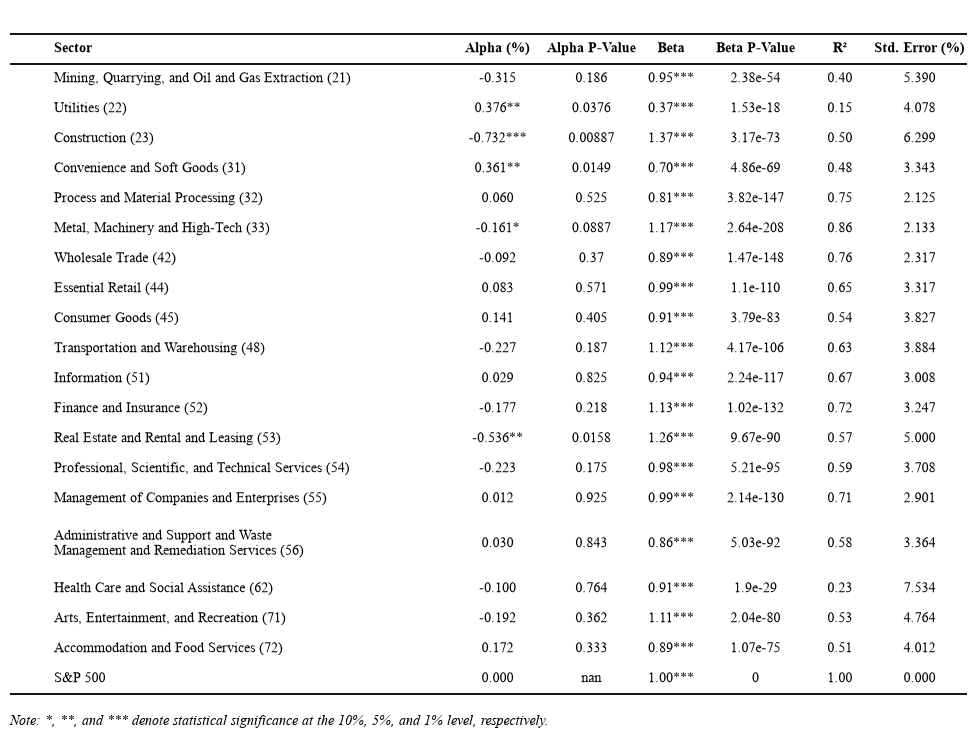

In [25]:
## OLS-Regression je Sektor und Index berechnen

from scipy.stats import linregress
from scipy.stats import t as t_verteilung

markt_excess = df_returns_rf['ret_index'] - df_returns_rf['DTB3']

regression_ergebnisse = {}
for spalte in df_returns.columns:
    asset_excess = df_returns_rf[spalte] - df_returns_rf['DTB3']
    daten = pd.concat([asset_excess, markt_excess], axis=1).dropna()
    daten.columns = ['asset', 'markt']

    n = len(daten)
    regression = linregress(daten['markt'], daten['asset'])

    # Standardfehler und p-Wert für Alpha (Achsenabschnitt) berechnen
    residuen = daten['asset'] - (regression.intercept + regression.slope * daten['markt'])
    s_residuen = np.sqrt(np.sum(residuen**2) / (n - 2))
    x_mean = daten['markt'].mean()
    ss_x = np.sum((daten['markt'] - x_mean)**2)

    se_alpha = s_residuen * np.sqrt(1/n + x_mean**2/ss_x)
    t_stat_alpha = regression.intercept / se_alpha
    p_wert_alpha = 2 * (1 - t_verteilung.cdf(abs(t_stat_alpha), df=n-2))

    regression_ergebnisse[spalte] = {
        'alpha': regression.intercept,
        'alpha_p_wert': p_wert_alpha,
        'beta': regression.slope,
        'beta_p_wert': regression.pvalue,
        'r_quadrat': regression.rvalue ** 2,
        'standardfehler': regression.stderr
    }

df_regression = pd.DataFrame(regression_ergebnisse).T

df_regression.index = df_regression.index.map(sektor_name)
df_regression = df_regression.rename(index={'ret_index': 'S&P 500'})

df_regression.to_excel("sektor_regression.xlsx", sheet_name="OLS Regression", index=True)

df_regression

## df_regression als table plot (mit Signifikanz-Sternchen)
import re
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Times New Roman'

def signifikanz_sterne(p):
    if p < 0.01:
        return '***'
    elif p < 0.05:
        return '**'
    elif p < 0.10:
        return '*'
    else:
        return ''

tabelle = df_regression.reset_index()
tabelle = tabelle.rename(columns={'index': 'Sector'})

def sortier_schluessel(name):
    if name == 'S&P 500':
        return float('inf')
    match = re.search(r'\((\d+)\)$', name)
    return int(match.group(1)) if match else float('inf') - 1

tabelle['sortier_key'] = tabelle['Sector'].map(sortier_schluessel)
tabelle = tabelle.sort_values('sortier_key').drop(columns='sortier_key')

tabelle['Sector'] = tabelle['Sector'].str.replace(
    'Administrative and Support and Waste Management and Remediation Services',
    'Administrative and Support and Waste\nManagement and Remediation Services',
    regex=False
)

# Sternchen berechnen, bevor die Werte in Strings umgewandelt werden
tabelle['beta_sterne'] = tabelle['beta_p_wert'].map(signifikanz_sterne)
tabelle['alpha_sterne'] = tabelle['alpha_p_wert'].map(signifikanz_sterne)

# formatieren und Sternchen anhängen
tabelle['Alpha'] = (tabelle['alpha'] * 100).round(3).map(lambda x: f'{x:,.3f}') + tabelle['alpha_sterne']
tabelle['Beta'] = tabelle['beta'].round(2).map(lambda x: f'{x:,.2f}') + tabelle['beta_sterne']
tabelle['R²'] = tabelle['r_quadrat'].round(2).map(lambda x: f'{x:,.2f}')
tabelle['Std. Error'] = (tabelle['standardfehler'] * 100).round(3).map(lambda x: f'{x:,.3f}')
tabelle['Beta P-Value'] = tabelle['beta_p_wert'].map(lambda x: f'{x:.3g}')
tabelle['Alpha P-Value'] = tabelle['alpha_p_wert'].map(lambda x: f'{x:.3g}')

tabelle = tabelle[['Sector', 'Alpha', 'Alpha P-Value', 'Beta', 'Beta P-Value', 'R²', 'Std. Error']]

col_labels = ['Sector', 'Alpha (%)', 'Alpha P-Value', 'Beta', 'Beta P-Value', 'R²', 'Std. Error (%)']

n_rows = len(tabelle)
n_cols = len(col_labels)

col_widths = [0.47, 0.10, 0.10, 0.07, 0.11, 0.07, 0.10]

fig, ax = plt.subplots(figsize=(1.3 * n_cols + 3, 0.42 * n_rows + 0.8))
ax.axis('off')

tab = ax.table(
    cellText=tabelle.values,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
    colWidths=col_widths
)

tab.auto_set_font_size(False)
tab.set_fontsize(10)
tab.scale(1, 1.8)

umbruch_zeilen = [i + 1 for i, name in enumerate(tabelle['Sector']) if '\n' in name]

for (row, col), cell in tab.get_celld().items():
    cell.set_linewidth(0)
    cell.visible_edges = ''
    cell.set_text_props(fontfamily='Times New Roman')
    if col == 0:
        cell.set_text_props(ha='left', fontfamily='Times New Roman')
    if row == 0:
        cell.set_text_props(weight='bold', fontfamily='Times New Roman')
        cell.visible_edges = 'B'
        cell.set_linewidth(1.3)
    if row in umbruch_zeilen:
        cell.set_height(cell.get_height() * 2)

fig.canvas.draw()
bbox = tab.get_window_extent(fig.canvas.get_renderer()).transformed(ax.transAxes.inverted())

ax.hlines([bbox.y1, bbox.y0], xmin=bbox.x0, xmax=bbox.x1, transform=ax.transAxes,
          color='black', linewidth=1.3, clip_on=False)

# Fußnote zur Signifikanz-Notation
ax.text(
    bbox.x0, bbox.y0 - 0.03,
    'Note: *, **, and *** denote statistical significance at the 10%, 5%, and 1% level, respectively.',
    transform=ax.transAxes,
    ha='left', va='top',
    fontsize=10, fontstyle='italic',
    fontfamily='Times New Roman'
)

plt.savefig('regression_table.png', dpi=1000, bbox_inches='tight', pad_inches=0.05, facecolor='white')
plt.show()

Summe col_widths: 1.0


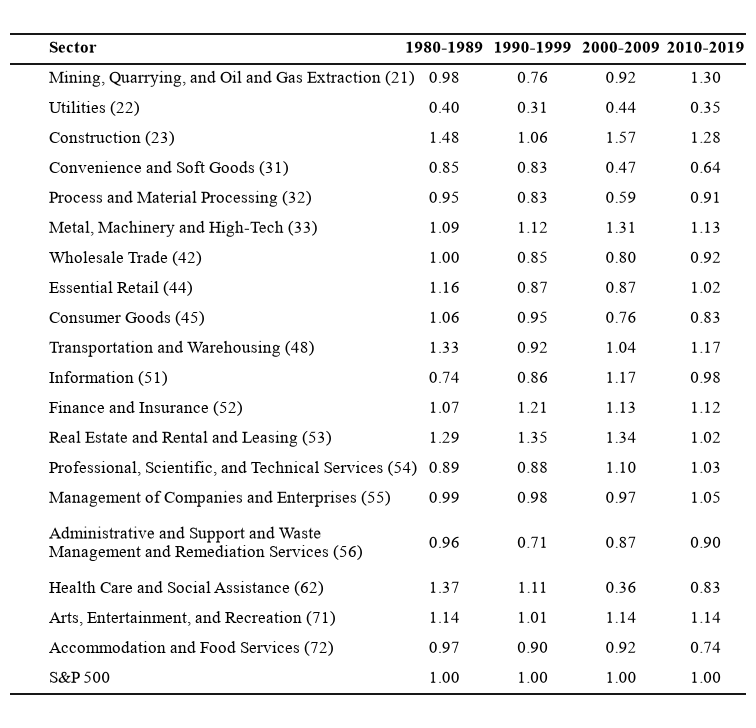

In [12]:
## 10-Jahres-Beta je Sektor berechnen (rollierende, nicht überlappende Perioden)

markt_excess = df_returns_rf['ret_index'] - df_returns_rf['DTB3']

# 10-Jahres-Perioden definieren: 1980-1989, 1990-1999, 2000-2009, 2010-2019
perioden = [(1980 + 10*i, 1980 + 10*i + 9) for i in range(4)]

beta_10j = {}

for spalte in df_returns.columns:
    asset_excess = df_returns_rf[spalte] - df_returns_rf['DTB3']

    beta_je_periode = {}
    for start_jahr, end_jahr in perioden:
        maske = (df_returns_rf.index.year >= start_jahr) & (df_returns_rf.index.year <= end_jahr)
        daten = pd.concat([asset_excess[maske], markt_excess[maske]], axis=1).dropna()
        daten.columns = ['asset', 'markt']

        cov_matrix = np.cov(daten['asset'], daten['markt'])
        beta = cov_matrix[0, 1] / cov_matrix[1, 1]

        spalten_label = f'{start_jahr}-{end_jahr}'
        beta_je_periode[spalten_label] = beta

    beta_10j[spalte] = beta_je_periode

df_beta_10j = pd.DataFrame(beta_10j).T

df_beta_10j.index = df_beta_10j.index.map(sektor_name)
df_beta_10j = df_beta_10j.rename(index={'ret_index': 'S&P 500'})

df_beta_10j.to_excel("beta_10jahre.xlsx", sheet_name="10-Year Beta", index=True)

df_beta_10j

## df_beta_10j als table plot
import re
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Times New Roman'

tabelle = df_beta_10j.reset_index()
tabelle = tabelle.rename(columns={'index': 'Sector'})

def sortier_schluessel(name):
    if name == 'S&P 500':
        return float('inf')
    match = re.search(r'\((\d+)\)$', name)
    return int(match.group(1)) if match else float('inf') - 1

tabelle['sortier_key'] = tabelle['Sector'].map(sortier_schluessel)
tabelle = tabelle.sort_values('sortier_key').drop(columns='sortier_key')

tabelle['Sector'] = tabelle['Sector'].str.replace(
    'Administrative and Support and Waste Management and Remediation Services',
    'Administrative and Support and Waste\nManagement and Remediation Services',
    regex=False
)

perioden_spalten = [c for c in tabelle.columns if c != 'Sector']
for spalte in perioden_spalten:
    tabelle[spalte] = tabelle[spalte].round(2).map(lambda x: f'{x:,.2f}')

col_labels = list(tabelle.columns)

n_rows = len(tabelle)
n_cols = len(col_labels)

# ============================================
# MANUELLE SPALTENBREITEN — hier direkt anpassen
# Reihenfolge: [Sector, 1980-1989, 1990-1999, 2000-2009, 2010-2019]
# Werte sind Anteile der Gesamtbreite und sollten sich zu ca. 1.0 aufsummieren
# ============================================
col_widths = [0.53, 0.12, 0.12, 0.12, 0.11]

print("Summe col_widths:", sum(col_widths))   # sollte nah bei 1.0 liegen

fig, ax = plt.subplots(figsize=(1.3 * n_cols + 3, 0.42 * n_rows + 0.8))
ax.axis('off')

tab = ax.table(
    cellText=tabelle.values,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
    colWidths=col_widths
)

tab.auto_set_font_size(False)
tab.set_fontsize(12)
tab.scale(1, 1.8)

umbruch_zeilen = [i + 1 for i, name in enumerate(tabelle['Sector']) if '\n' in name]

for (row, col), cell in tab.get_celld().items():
    cell.set_linewidth(0)
    cell.visible_edges = ''
    cell.set_text_props(fontfamily='Times New Roman')
    if col == 0:
        cell.set_text_props(ha='left', fontfamily='Times New Roman')
    if row == 0:
        cell.set_text_props(weight='bold', fontfamily='Times New Roman')
        cell.visible_edges = 'B'
        cell.set_linewidth(1.3)
    if row in umbruch_zeilen:
        cell.set_height(cell.get_height() * 2)

fig.canvas.draw()
bbox = tab.get_window_extent(fig.canvas.get_renderer()).transformed(ax.transAxes.inverted())

ax.hlines([bbox.y1, bbox.y0], xmin=bbox.x0, xmax=bbox.x1, transform=ax.transAxes,
          color='black', linewidth=1.3, clip_on=False)

plt.savefig('beta_10jahre_table.png', dpi=600, bbox_inches='tight', facecolor='white')
plt.show()

In [13]:
## drawdowns
# Maximum Drawdown je Sektor und Index in einem neuen DataFrame
max_drawdowns = {}

for spalte in df_returns.columns:
    # kumulierter Vermögensindex (Wachstum von 1 Einheit an, ausgehend vom monatlichen Return)
    kumulierter_wert = (1 + df_returns[spalte]).cumprod()
    
    # bisheriges Allzeithoch zu jedem Zeitpunkt
    laufendes_hoch = kumulierter_wert.cummax()
    
    # Drawdown = prozentualer Abstand vom bisherigen Höchststand
    drawdown = (kumulierter_wert / laufendes_hoch) - 1
    
    # maximaler (=größter) Drawdown über den gesamten Zeitraum
    max_drawdowns[spalte] = drawdown.min()

df_drawdowns = pd.DataFrame({'max_drawdown': pd.Series(max_drawdowns)})

drawdown_listen = []

for spalte in df_returns.columns:
    # kumulierter Vermögensindex und laufendes Allzeithoch
    kumulierter_wert = (1 + df_returns[spalte]).cumprod()
    laufendes_hoch = kumulierter_wert.cummax()
    drawdown = (kumulierter_wert / laufendes_hoch) - 1

    # Monate markieren, in denen wir "unter Wasser" sind (drawdown < 0)
    unter_wasser = drawdown < 0
    
    # jede zusammenhängende unter-Wasser-Periode bekommt eine eigene Gruppen-ID
    gruppe = (unter_wasser != unter_wasser.shift()).cumsum()

    # je Periode: Start, Ende, Länge und tiefster Punkt (=max. Drawdown dieser Periode)
    for gruppen_id, teil in drawdown[unter_wasser].groupby(gruppe[unter_wasser]):
        drawdown_listen.append({
            'sektor': spalte,
            'start': teil.index[0],
            'ende': teil.index[-1],
            'laenge_monate': len(teil),
            'max_drawdown': teil.min()
        })

df_alle_drawdowns = pd.DataFrame(drawdown_listen)
df_alle_drawdowns

## Maximum Drawdown, Länge und Anzahl aller Drawdowns je Sektor und Index

# je Sektor/Index die Zeile mit dem tiefsten Drawdown aus df_alle_drawdowns herausfinden
schlimmste_drawdowns = df_alle_drawdowns.loc[
    df_alle_drawdowns.groupby('sektor')['max_drawdown'].idxmin()
]

# schlimmster Drawdown und dessen Länge, Sektor/Index als Index
df_drawdowns = schlimmste_drawdowns.set_index('sektor')[['max_drawdown', 'laenge_monate']]


# Anzahl aller Drawdown-Episoden je Sektor/Index (unabhängig von deren Tiefe)
anzahl_drawdowns = df_alle_drawdowns.groupby('sektor').size()
df_drawdowns['anzahl_drawdowns'] = anzahl_drawdowns

#df_drawdowns.to_excel("max_drawdowns.xlsx", sheet_name="Max Drawdowns", index=True)
df_drawdowns

## Anzahl der Drawdowns je Sektor/Index nach Tiefe kategorisiert

# absolute Tiefe jedes einzelnen Drawdowns (in %) 
tiefe = df_alle_drawdowns['max_drawdown'].abs()

# Tiefen-Kategorien definieren: <10%, 10-20%, ..., 70-80%, >80%
grenzen = [0, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, np.inf]
labels = ['<10%', '10-20%', '20-30%', '30-40%', '40-50%', '50-60%', '60-70%', '70-80%', '>80%']

df_alle_drawdowns['tiefen_kategorie'] = pd.cut(tiefe, bins=grenzen, labels=labels)

# je Sektor/Index zählen, wie viele Drawdowns in welche Kategorie fallen
anzahl_je_kategorie = df_alle_drawdowns.pivot_table(
    index='sektor',
    columns='tiefen_kategorie',
    values='max_drawdown',
    aggfunc='count',
    fill_value=0,
    observed=False
)

# Spaltenreihenfolge festlegen und zu df_drawdowns hinzufügen
anzahl_je_kategorie = anzahl_je_kategorie[labels]
df_drawdowns = df_drawdowns.join(anzahl_je_kategorie)

#Namenszuordnung
df_drawdowns.index = df_drawdowns.index.map(sektor_name)
df_drawdowns = df_drawdowns.rename(index={'ret_index': 'S&P 500'})

#df_drawdowns.to_excel("max_drawdowns.xlsx", sheet_name="Max Drawdowns", index=True)
df_drawdowns

# Maximum Drawdown je Sektor und Index als Excel-Datei ausgeben
df_drawdowns.to_excel("max_drawdowns.xlsx", sheet_name="Max Drawdowns", index=True)

In [14]:
## df_drawdown als table plot
import re
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Times New Roman'

tabelle = df_drawdowns.reset_index()
tabelle = tabelle.rename(columns={
    'index': 'Sector',
    'sektor': 'Sector',
    'max_drawdown': 'Max Drawdown',
    'laenge_monate': 'Duration (Months)',
    'anzahl_drawdowns': 'Number of Drawdowns'
})

def sortier_schluessel(name):
    if name == 'S&P 500':
        return -1
    match = re.search(r'\((\d+)\)$', name)
    return int(match.group(1)) if match else float('inf')

tabelle['sortier_key'] = tabelle['Sector'].map(sortier_schluessel)
tabelle = tabelle.sort_values('sortier_key').drop(columns='sortier_key')

tabelle['Sector'] = tabelle['Sector'].str.replace(
    'Administrative and Support and Waste Management and Remediation Services',
    'Administrative and Support and Waste\nManagement and Remediation Services',
    regex=False
)

tabelle['Max Drawdown'] = (tabelle['Max Drawdown'] * 100).round(1).map(lambda x: f'{x:,.1f}')

for spalte in tabelle.columns:
    if spalte not in ['Sector', 'Max Drawdown']:
        tabelle[spalte] = tabelle[spalte].map(lambda x: f'{int(x):,}')

col_labels = list(tabelle.columns)
col_labels[col_labels.index('Max Drawdown')] = 'Max Drawdown (%)'

n_rows = len(tabelle)
n_cols = len(col_labels)

haupt_spalten = ['Sector', 'Max Drawdown (%)', 'Duration (Months)', 'Number of Drawdowns']
n_kategorie_spalten = n_cols - len(haupt_spalten)

sector_breite = 0.25

# individuelle Breiten für die drei Kern-Spalten
kern_breiten_übersteuerung = {
    'Max Drawdown (%)': 0.12,
    'Duration (Months)': 0.12,
    'Number of Drawdowns': 0.12,
}

# individuelle Breiten für einzelne Kategorie-Spalten
kategorie_labels = ['<10%', '10-20%', '20-30%', '30-40%', '40-50%', '50-60%', '60-70%', '70-80%', '>80%']

kategorie_breiten_übersteuerung = {
    '<10%': 0.06,
    '10-20%': 0.06, 
    '20-30%': 0.06,
    '30-40%': 0.06,
    '40-50%': 0.06,
    '50-60%':0.06,
    '60-70%': 0.06,
    '70-80%': 0.06,
    '>80%': 0.06,
}


col_widths = [sector_breite]
for spalte in haupt_spalten[1:]:
    col_widths.append(kern_breiten_übersteuerung[spalte])

for label in kategorie_labels:
    col_widths.append(kategorie_breiten_übersteuerung.get(label, standard_kategorie_breite))

fig, ax = plt.subplots(figsize=(1.55 * n_cols + 4.5, 0.5 * n_rows + 1.0))
ax.axis('off')

tab = ax.table(
    cellText=tabelle.values,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
    colWidths=col_widths
)

tab.auto_set_font_size(False)
tab.set_fontsize(17)
tab.scale(1, 2.0)

umbruch_zeilen = [i + 1 for i, name in enumerate(tabelle['Sector']) if '\n' in name]

for (row, col), cell in tab.get_celld().items():
    cell.set_linewidth(0)
    cell.visible_edges = ''
    cell.set_text_props(fontfamily='Times New Roman')
    if col >= len(haupt_spalten):
        cell.set_fontsize(17)
    if col == 0:
        cell.set_text_props(ha='left', fontfamily='Times New Roman')
    if row == 0:
        cell.set_text_props(weight='bold', fontfamily='Times New Roman')
        cell.visible_edges = 'B'
        cell.set_linewidth(1.3)
    if row in umbruch_zeilen:
        cell.set_height(cell.get_height() * 2)

fig.canvas.draw()
bbox = tab.get_window_extent(fig.canvas.get_renderer()).transformed(ax.transAxes.inverted())

ax.hlines([bbox.y1, bbox.y0], xmin=bbox.x0, xmax=bbox.x1, transform=ax.transAxes,
          color='black', linewidth=1.3, clip_on=False)

plt.savefig('drawdowns_table.png', dpi=1000, bbox_inches='tight', facecolor='white')
plt.show()

NameError: name 'standard_kategorie_breite' is not defined

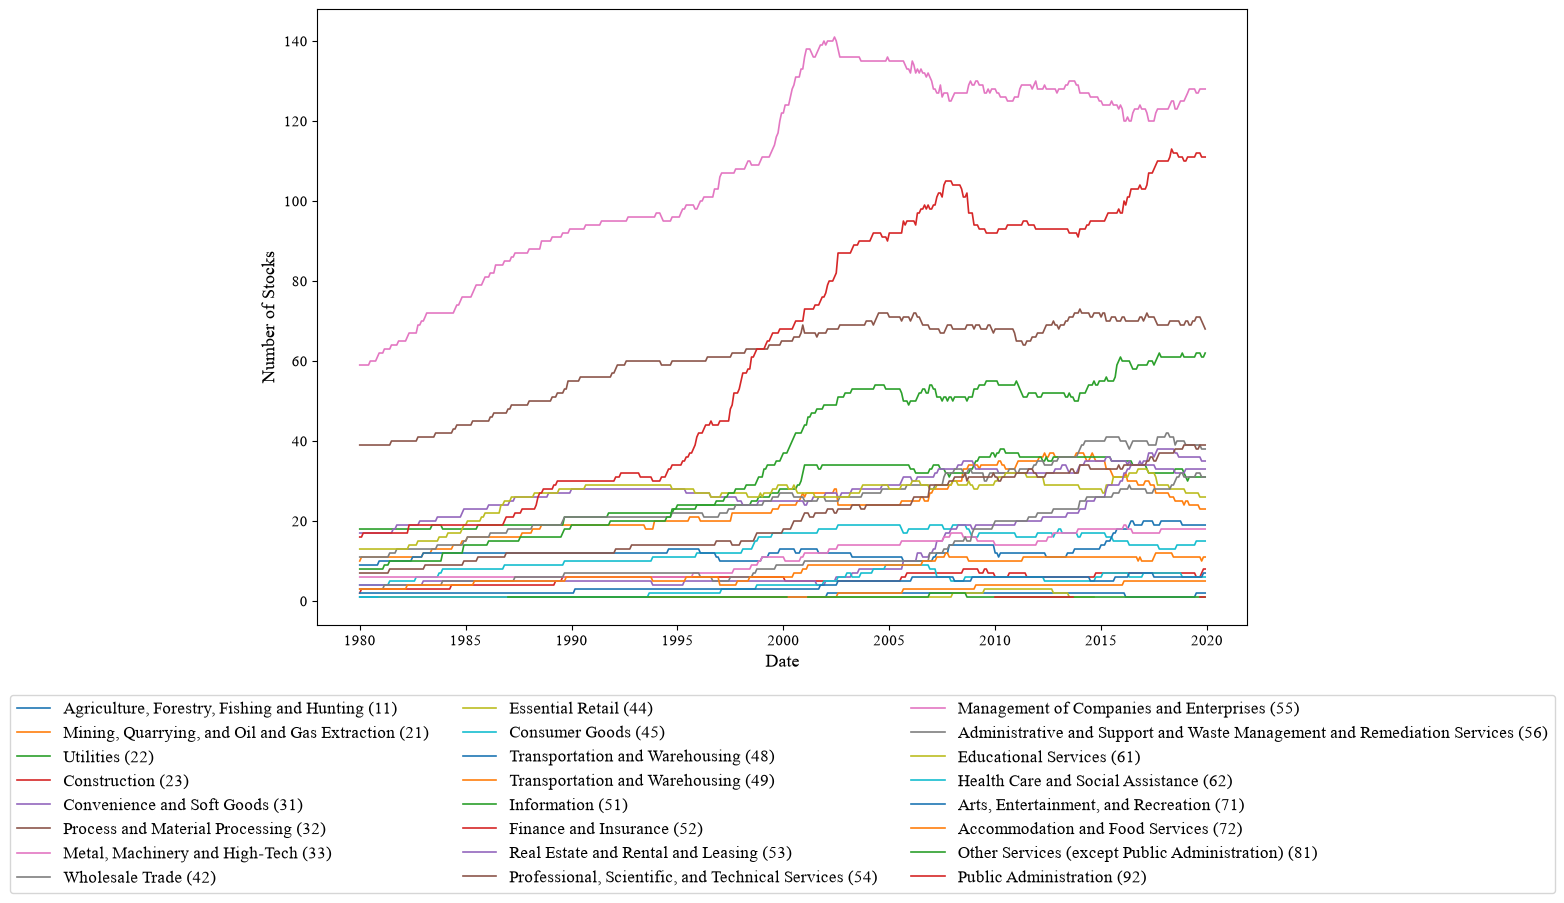

In [ ]:
## Anzahl der Aktien je Sektor und Monat berechnen (inkl. Sektoren mit <10 Aktien)

# eigene, ungefilterte Sektor-Zuordnung aus df_stocks_merged aufbauen
df_sectors_alle = df_stocks_merged[['permno', 'naics']].copy()
df_sectors_alle = df_sectors_alle.dropna(subset=['naics'])
df_sectors_alle['naics'] = df_sectors_alle['naics'].round(0).astype(int).astype(str).str[:2]
df_sectors_alle['permno'] = df_sectors_alle['permno'].round(0).astype(int)
df_sectors_alle = df_sectors_alle.drop_duplicates()

# mit df_merged (permno + date, aus dem SPX-Index) zusammenführen
df_sectors_alle_merge = df_sectors_alle.copy()
df_sectors_alle_merge['permno'] = df_sectors_alle_merge['permno'].astype(df_merged['permno'].dtype)

df_merged_alle_sektoren = df_merged.merge(df_sectors_alle_merge, on='permno', how='left')

# Anzahl Aktien je Sektor und Monat, inkl. kleiner Sektoren
anzahl_aktien = df_merged_alle_sektoren.groupby(['date', 'naics'])['permno'].nunique()
anzahl_aktien_wide = anzahl_aktien.unstack('naics')

# nur Zeitraum Januar 1980 bis Dezember 2019
anzahl_aktien_wide = anzahl_aktien_wide[
    (anzahl_aktien_wide.index >= '1980-01-01') &
    (anzahl_aktien_wide.index <= '2019-12-31')
]

anzahl_aktien_wide.columns = [sektor_name(c) for c in anzahl_aktien_wide.columns]

anzahl_aktien_wide.head()

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Times New Roman'

fig, ax = plt.subplots(figsize=(12, 8))

for spalte in anzahl_aktien_wide.columns:
    ax.plot(anzahl_aktien_wide.index, anzahl_aktien_wide[spalte], label=spalte, linewidth=1.2)

ax.set_xlabel('Date', fontfamily='Times New Roman', fontsize=13)
ax.set_ylabel('Number of Stocks', fontfamily='Times New Roman', fontsize=13)
ax.tick_params(axis='both', labelsize=11)

# Legende unterhalb der Grafik, auf mehrere Spalten verteilt
ax.legend(
    prop={'family': 'Times New Roman', 'size': 11},
    loc='upper center',
    bbox_to_anchor=(0.5, -0.10),
    ncol=3,
    )

plt.savefig('anzahl_aktien_zeitreihe.png', dpi=600, bbox_inches='tight', facecolor='white')
plt.show()

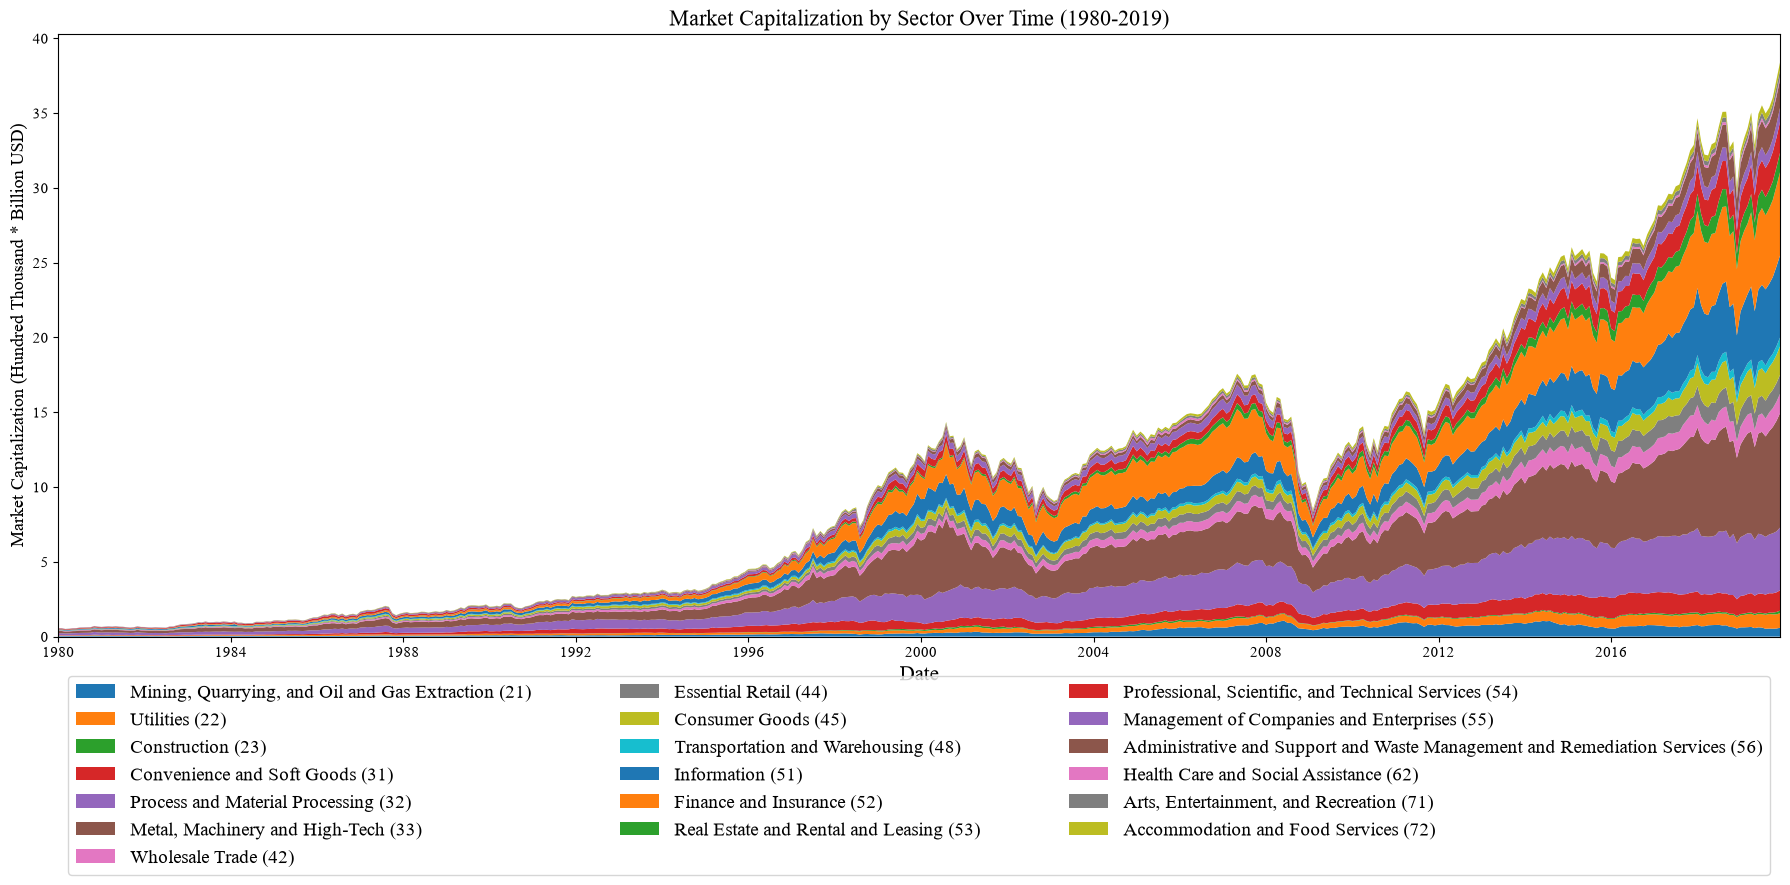

In [ ]:
## plotting1

## Area plot of market capitalization by sector over time

import matplotlib.ticker as mticker
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Times New Roman'

# convert sector mcap (MultiIndex: date, naics) to wide format (sectors as columns)
sektor_mcap_wide = sektor_mcap_zeitraum.unstack('naics')
sektor_mcap_wide.columns = sektor_mcap_wide.columns.map(sektor_name)

# fill missing values (if a sector has no mcap in a given month) with 0
sektor_mcap_wide = sektor_mcap_wide.fillna(0)
#WIE HÄUFIG KOMMT DAS VOR? FEHLEN HIER DATEN?

# stacked area plot
fig, ax = plt.subplots(figsize=(18, 9))
ax.stackplot(
    sektor_mcap_wide.index,
    sektor_mcap_wide.T.values,
    labels=sektor_mcap_wide.columns
)

# x-Achse exakt auf den Datenbereich begrenzen (kein Puffer links/rechts)
ax.set_xlim(sektor_mcap_wide.index.min(), sektor_mcap_wide.index.max())

# y-Achse bei 0 beginnen lassen (kein Puffer unten), oben automatisch
ax.set_ylim(bottom=0)

ax.set_title('Market Capitalization by Sector Over Time (1980-2019)', fontsize=16)
ax.set_xlabel('Date', fontsize=15)
ax.set_ylabel('Market Capitalization (Hundred Thousand * Billion USD)', fontsize=13)
ax.tick_params(axis='both', labelsize=11)

# format y-axis: divide raw values (in USD) by 1e9 to show them in billions
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'{x / 1e9:.0f}'))

ax.legend(
    loc='upper center',
    bbox_to_anchor=(0., -0.15, 1., .1),   # (x0, y0, breite, höhe) -> volle Breite = 1.
    mode="expand",                          # streckt die Legende über die gesamte Breite
    ncol=3,
    fontsize='14'
)

plt.tight_layout()
plt.savefig('mcap_area_plot.png', dpi=600, bbox_inches='tight', pad_inches=0.05, facecolor='white')
plt.show()

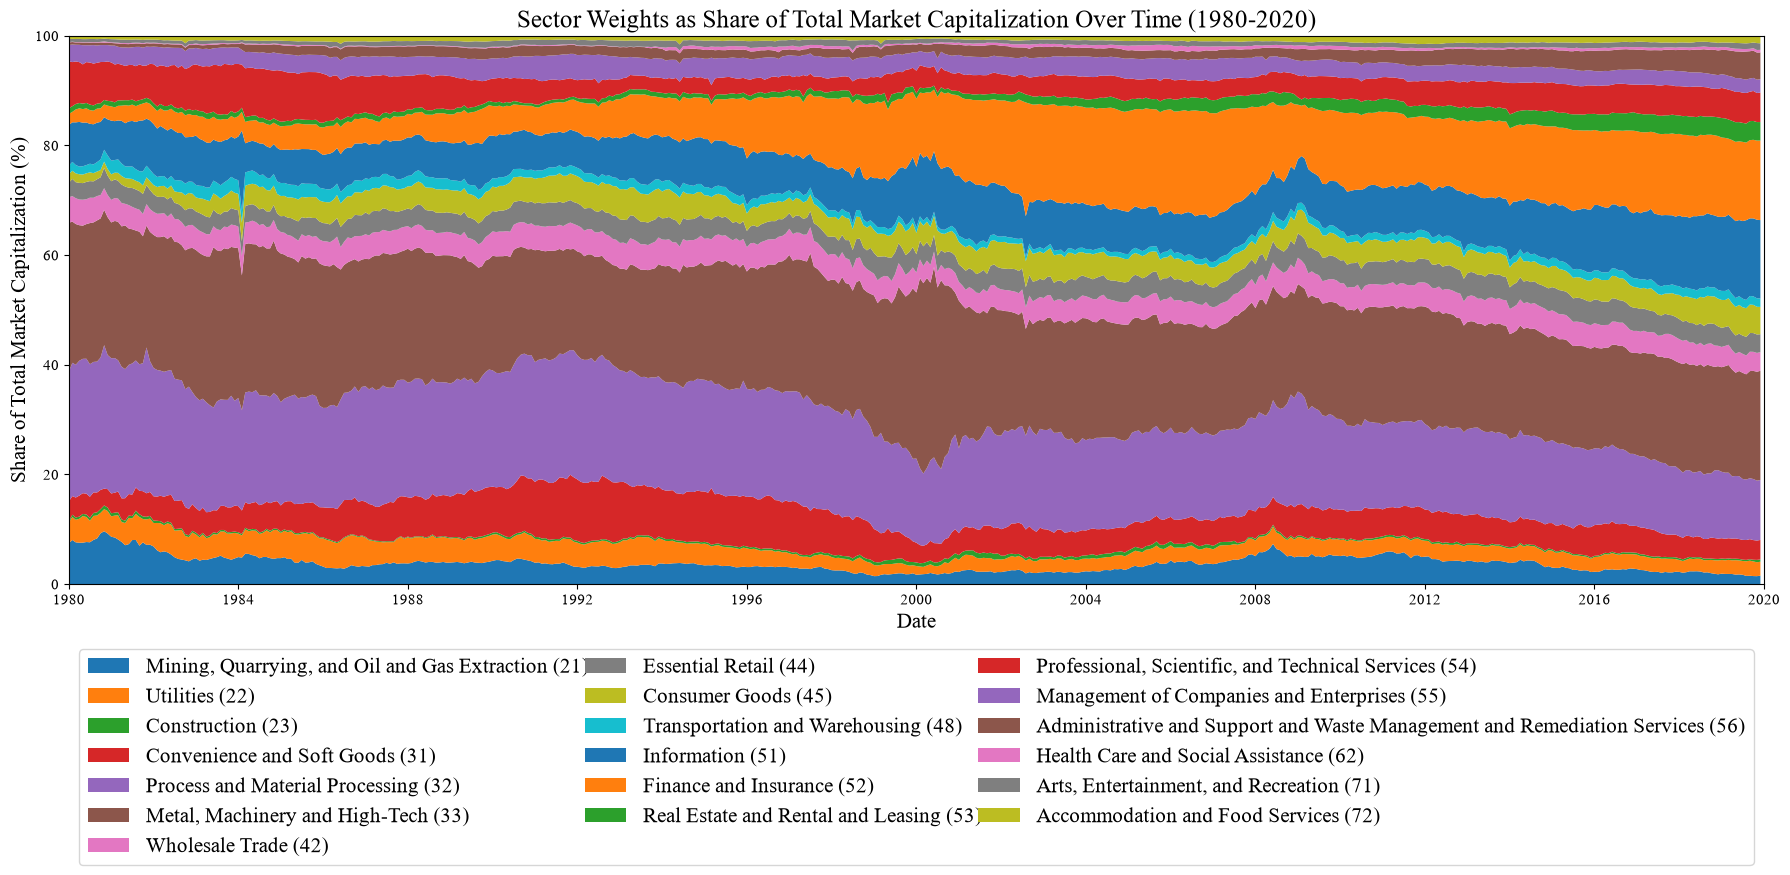

In [ ]:
## Area plot of sector weights (% of total market cap) over time

import matplotlib.ticker as mticker
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['font.family'] = 'Times New Roman'

# Sektor-Marktkapitalisierung in wide-Format (falls noch nicht vorhanden)
sektor_mcap_wide = sektor_mcap_zeitraum.unstack('naics')
sektor_mcap_wide.columns = sektor_mcap_wide.columns.map(sektor_name)
sektor_mcap_wide = sektor_mcap_wide.fillna(0)

# Gesamte Marktkapitalisierung aller Sektoren je Monat (= Summe über alle Sektoren)
gesamt_mcap_je_monat = sektor_mcap_wide.sum(axis=1)

# Gewicht jedes Sektors = eigene Mcap / gesamte Mcap in diesem Monat (in %)
sektor_gewichte = sektor_mcap_wide.div(gesamt_mcap_je_monat, axis=0) * 100

# stacked area plot der Gewichte
fig, ax = plt.subplots(figsize=(18, 9))
ax.stackplot(
    sektor_gewichte.index,
    sektor_gewichte.T.values,
    labels=sektor_gewichte.columns
)

ax.set_title('Sector Weights as Share of Total Market Capitalization Over Time (1980-2020)', fontsize=18)
ax.set_xlabel('Date', fontsize=15)
ax.set_ylabel('Share of Total Market Capitalization (%)', fontsize=15)
ax.tick_params(axis='both', labelsize=11)

import pandas as pd

# Ränder entfernen, aber kleinen Puffer rechts lassen, damit "2020" noch angezeigt wird
ax.set_xlim(sektor_gewichte.index.min(), sektor_gewichte.index.max() + pd.Timedelta(days=31))
ax.set_ylim(0, 100)

ax.legend(
    loc='upper center',
    bbox_to_anchor=(0., -0.20, 1., .1),
    mode="expand",
    ncol=3,
    prop={'family': 'Times New Roman', 'size': 15}
)

plt.tight_layout()
plt.savefig('sektor_gewichte_area_plot.png', dpi=600, bbox_inches='tight', pad_inches=0.05, facecolor='white')
plt.show()

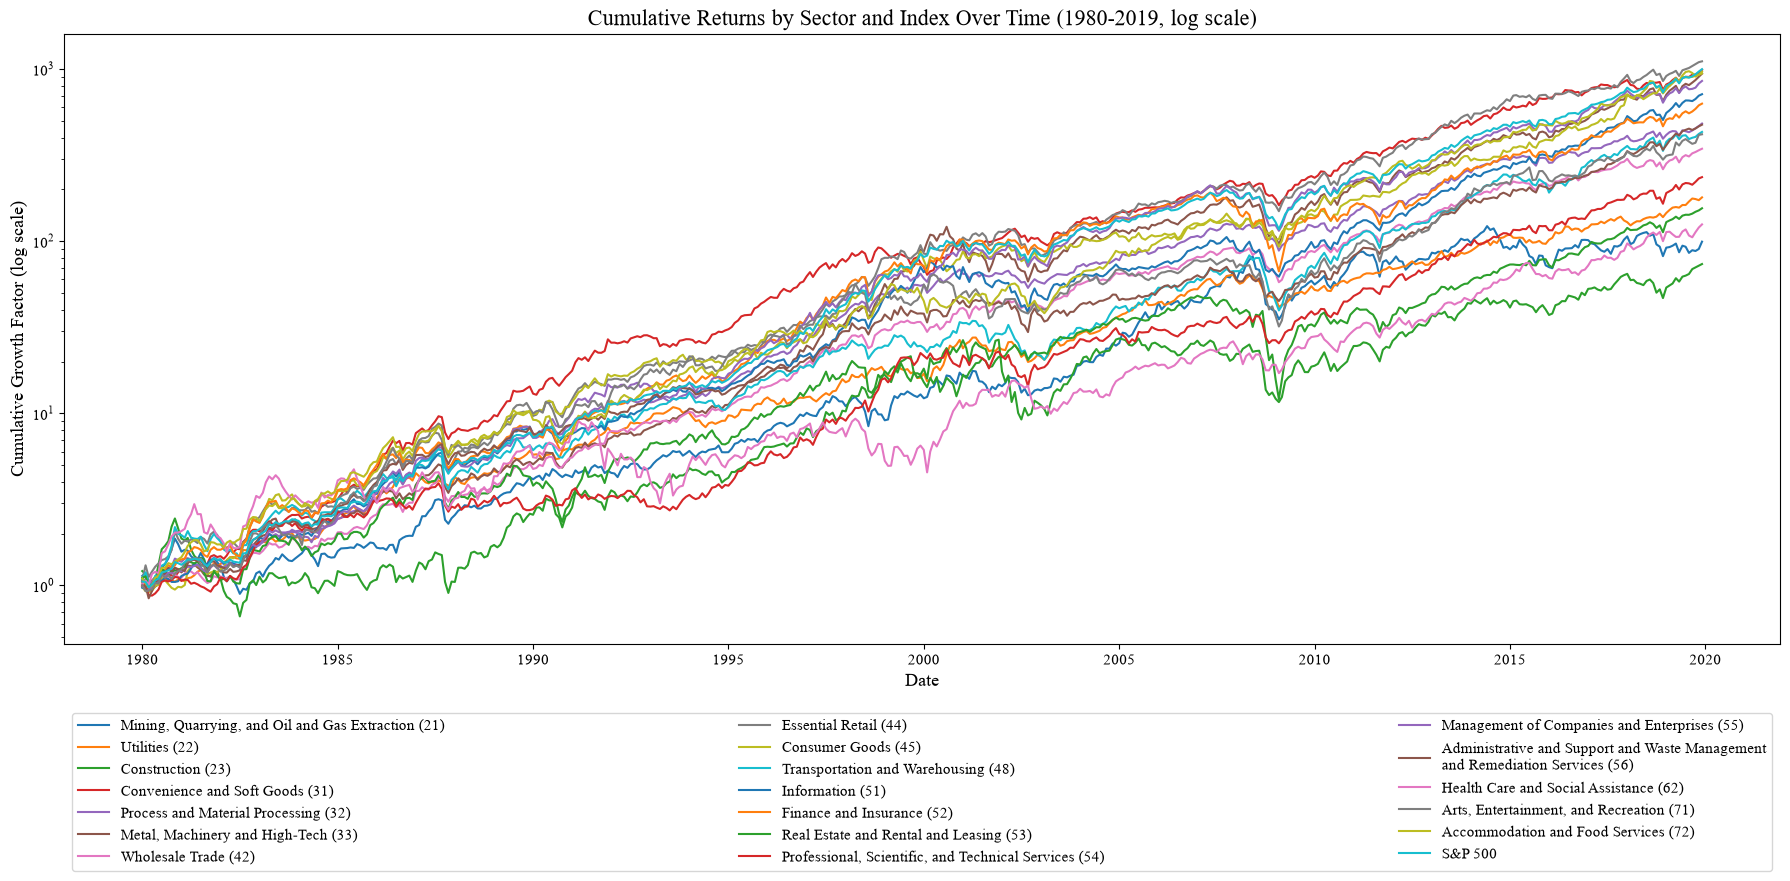

In [ ]:
## plotting2

## Line plot of cumulative returns (in %) by sector and index over time

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Times New Roman'

# cumulative growth of 1 unit invested, based on monthly returns
kumulierte_returns = (1 + df_returns).cumprod()
kumulierte_returns.columns = kumulierte_returns.columns.map(sektor_name)
kumulierte_returns = kumulierte_returns.rename(columns={'ret_index': 'S&P 500'})

# Zeilenumbruch für den langen Sektornamen (56)
kumulierte_returns = kumulierte_returns.rename(columns={
    'Administrative and Support and Waste Management and Remediation Services (56)':
        'Administrative and Support and Waste Management\nand Remediation Services (56)'
})

# convert to cumulative return in percent (e.g. growth factor 2.5 -> +150%)
kumulierte_returns_prozent = (kumulierte_returns - 1) * 100

fig, ax = plt.subplots(figsize=(18, 9))
for spalte in kumulierte_returns.columns:
    ax.plot(kumulierte_returns.index, kumulierte_returns[spalte], label=spalte)

ax.set_yscale('log')  # logarithmische y-Achse

ax.set_title('Cumulative Returns by Sector and Index Over Time (1980-2019, log scale)', fontsize=16)
ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('Cumulative Growth Factor (log scale)', fontsize=13)
ax.tick_params(axis='both', labelsize=11)

# Legende unterhalb der Grafik, auf 3 Spalten verteilt, mit etwas mehr Abstand zur x-Achse
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0., -0.20, 1., .1),   # y0 von -0.15 auf -0.20 -> mehr Abstand
    mode="expand",
    ncol=3,                                 # war: 4
    fontsize=11                             # war: 'small'
)

plt.tight_layout()
plt.savefig('cumulative_returns_plot.png', dpi=600, bbox_inches='tight', facecolor='white')
plt.show()

Stichtag: 2019-12-01 00:00:00


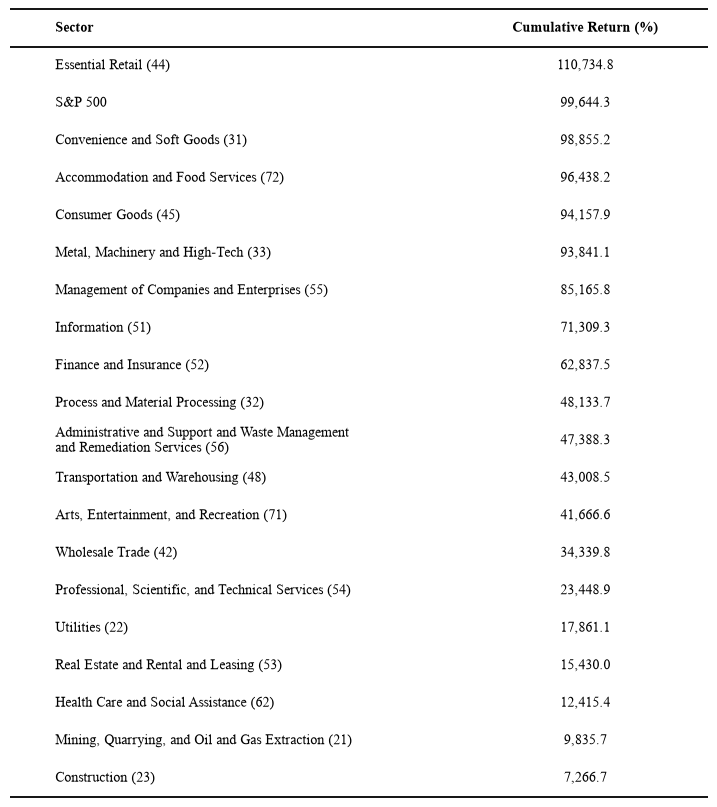

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Times New Roman'

# Letzte verfügbare Zeile (Ende des Betrachtungszeitraums)
stichtag = kumulierte_returns_prozent.iloc[-1].sort_values(ascending=False)
print("Stichtag:", kumulierte_returns_prozent.index[-1])  # zur Kontrolle

tabelle = stichtag.round(1).reset_index()
tabelle.columns = ['Sector', 'Cumulative Return']
tabelle['Cumulative Return'] = tabelle['Cumulative Return'].map(lambda x: f'{x:,.1f}')

col_labels = ['Sector', 'Cumulative Return (%)']
n_rows = len(tabelle)

fig, ax = plt.subplots(figsize=(9, 0.32 * n_rows + 0.6))
ax.axis('off')

tab = ax.table(
    cellText=tabelle.values,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
    colWidths=[0.65, 0.35]
)

tab.auto_set_font_size(False)
tab.set_fontsize(12)
tab.scale(1, 1.5)

tab.auto_set_font_size(False)
tab.set_fontsize(10)
tab.scale(1, 1.5)

# NEU: Zeilen mit Zeilenumbruch im Sector-Namen identifizieren
umbruch_zeilen = [i + 1 for i, name in enumerate(tabelle['Sector']) if '\n' in name]

for (row, col), cell in tab.get_celld().items():
    cell.set_linewidth(0)
    cell.visible_edges = ''
    cell.set_text_props(fontfamily='Times New Roman')
    if col == 0:
        cell.set_text_props(ha='left', fontfamily='Times New Roman')
    if row == 0:
        cell.set_text_props(weight='bold', fontfamily='Times New Roman')
        cell.visible_edges = 'B'
        cell.set_linewidth(1.3)

fig.canvas.draw()
bbox = tab.get_window_extent(fig.canvas.get_renderer()).transformed(ax.transAxes.inverted())
ax.hlines([bbox.y1, bbox.y0], xmin=bbox.x0, xmax=bbox.x1, transform=ax.transAxes,
          color='black', linewidth=1.3, clip_on=False)

plt.savefig('cumulative_returns_2019.png', dpi=600, bbox_inches='tight', facecolor='white')
plt.show()